# Experiment: Heart Disease — Decision Tree Classification
**Dataset:** Heart Disease (Cleveland) | **Course Outcome:** CO3 | **Environment:** VS Code

In [1]:
# Cell 1 — Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, mean_squared_error

In [2]:
# Cell 2 — Load the data
heart = pd.read_csv("heart.csv")
print(heart.shape)
print("missing values:", heart.isna().sum().sum())
print(heart["target"].value_counts())
heart.head()

(303, 14)
missing values: 0
target
1.0    165
0.0    138
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1.0


In [3]:
# Cell 3 — Check which value of target means diseased
print(heart.groupby("target")[["thalach", "exang", "ca", "oldpeak"]].mean().round(2))

        thalach  exang    ca  oldpeak
target                               
0.0      139.10   0.55  1.17     1.59
1.0      158.47   0.14  0.36     0.58


In [4]:
# Cell 4 — Split into train, validation and test
X = heart.drop(columns="target")
y = heart["target"].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)
print("baseline:", round(y_val.value_counts(normalize=True).max(), 4))

(212, 13) (45, 13) (46, 13)
baseline: 0.5556


In [5]:
# Cell 5 — Fit a tree with no size limit
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

train_acc = accuracy_score(y_train, full_tree.predict(X_train))
val_acc = accuracy_score(y_val, full_tree.predict(X_val))

print("train  :", round(train_acc, 4))
print("val    :", round(val_acc, 4))
print("gap    :", round(train_acc - val_acc, 4))
print("depth  :", full_tree.get_depth())
print("leaves :", full_tree.get_n_leaves())

train  : 1.0
val    : 0.7333
gap    : 0.2667
depth  : 8
leaves : 35


In [6]:
# Cell 6 — Gini or entropy?
for criterion in ["gini", "entropy"]:
    t = DecisionTreeClassifier(criterion=criterion, random_state=42)
    t.fit(X_train, y_train)
    print("%-8s depth %-3d leaves %-3d train %.4f val %.4f" % (
        criterion, t.get_depth(), t.get_n_leaves(),
        accuracy_score(y_train, t.predict(X_train)),
        accuracy_score(y_val, t.predict(X_val))))

for criterion in ["gini", "entropy"]:
    t = DecisionTreeClassifier(criterion=criterion, max_depth=4, random_state=42)
    t.fit(X_train, y_train)
    print("%-8s at depth 4: val %.4f" % (
        criterion, accuracy_score(y_val, t.predict(X_val))))

gini     depth 8   leaves 35  train 1.0000 val 0.7333
entropy  depth 11  leaves 32  train 1.0000 val 0.6889
gini     at depth 4: val 0.8000
entropy  at depth 4: val 0.7556


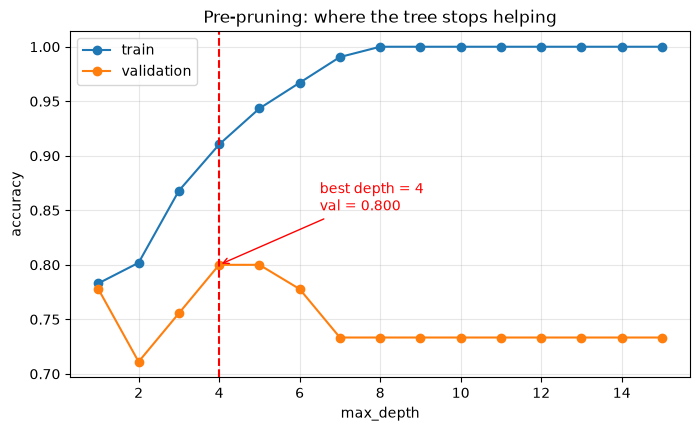

In [7]:
# Cell 7 — Pre-pruning: sweep max_depth
depths = range(1, 16)
train_scores, val_scores = [], []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    t.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, t.predict(X_train)))
    val_scores.append(accuracy_score(y_val, t.predict(X_val)))

best_depth = list(depths)[int(np.argmax(val_scores))]

plt.figure(figsize=(8, 4.5))
plt.plot(list(depths), train_scores, marker="o", label="train")
plt.plot(list(depths), val_scores, marker="o", label="validation")
plt.axvline(best_depth, color="red", linestyle="--")
plt.annotate("best depth = %d\nval = %.3f" % (best_depth, max(val_scores)),
             xy=(best_depth, max(val_scores)),
             xytext=(best_depth + 2.5, 0.85),
             arrowprops=dict(arrowstyle="->", color="red"), color="red")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.title("Pre-pruning: where the tree stops helping")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("pre_pruning_curve.png")
plt.show()

In [8]:
# Cell 8 — Post-pruning with ccp_alpha
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]
print("alphas:", len(alphas), "from %.5f to %.5f" % (alphas.min(), alphas.max()))

rows = []
for a in alphas:
    t = DecisionTreeClassifier(ccp_alpha=a, random_state=42)
    t.fit(X_train, y_train)
    rows.append({"alpha": a, "leaves": t.get_n_leaves(),
                 "train": accuracy_score(y_train, t.predict(X_train)),
                 "val": accuracy_score(y_val, t.predict(X_val))})

pruning = pd.DataFrame(rows)
best_alpha = pruning.loc[pruning["val"].idxmax(), "alpha"]
print("best alpha: %.5f" % best_alpha)
print(pruning.round(5))

alphas: 18 from 0.00000 to 0.05350
best alpha: 0.00663
      alpha  leaves    train      val
0   0.00000      35  1.00000  0.73333
1   0.00432      33  0.99528  0.73333
2   0.00435      31  0.99057  0.73333
3   0.00463      29  0.98585  0.75556
4   0.00663      25  0.97170  0.77778
5   0.00686      22  0.95755  0.77778
6   0.00697      16  0.92925  0.73333
7   0.00732      15  0.92453  0.75556
8   0.00746      14  0.91981  0.75556
9   0.00837      13  0.91509  0.75556
10  0.01132      12  0.90566  0.75556
11  0.01171      11  0.89623  0.75556
12  0.01178       8  0.87736  0.73333
13  0.01273       7  0.87264  0.75556
14  0.01447       5  0.83491  0.77778
15  0.01912       4  0.80189  0.71111
16  0.02673       3  0.80189  0.71111
17  0.05350       2  0.78302  0.77778


full     leaves 35   train 1.0000 val 0.7333 test 0.7174
depth    leaves 15   train 0.9104 val 0.8000 test 0.7609
pruned   leaves 25   train 0.9717 val 0.7778 test 0.6957
cp          0.4409
oldpeak     0.2200
thal        0.1099
ca          0.0533
age         0.0465
trestbps    0.0413
thalach     0.0329
sex         0.0326
slope       0.0225
dtype: float64


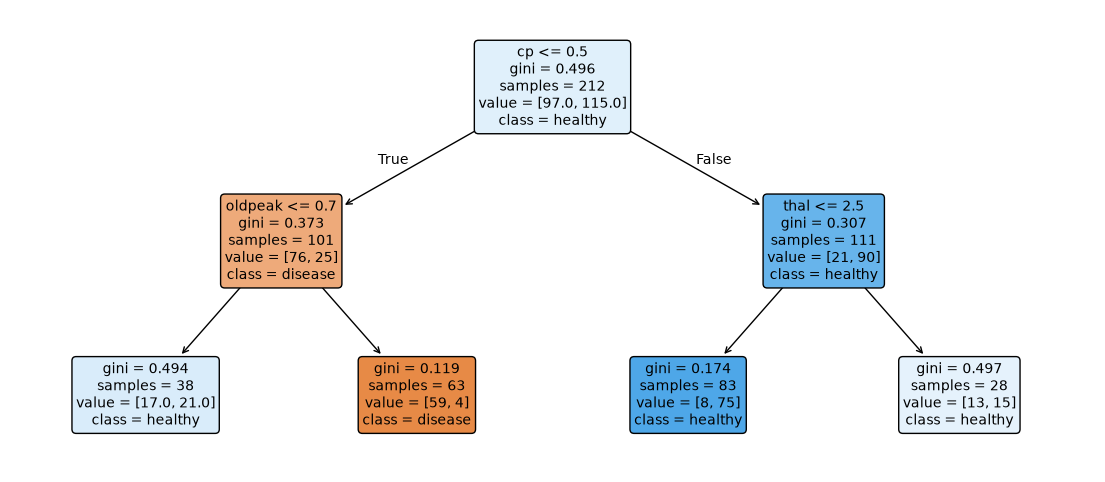

In [9]:
# Cell 9 — Compare the three trees
depth_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
depth_tree.fit(X_train, y_train)
pruned_tree = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
pruned_tree.fit(X_train, y_train)

for name, t in [("full", full_tree), ("depth", depth_tree), ("pruned", pruned_tree)]:
    print("%-8s leaves %-4d train %.4f val %.4f test %.4f" % (
        name, t.get_n_leaves(),
        accuracy_score(y_train, t.predict(X_train)),
        accuracy_score(y_val, t.predict(X_val)),
        accuracy_score(y_test, t.predict(X_test))))

importance = pd.Series(depth_tree.feature_importances_, index=X.columns)
print(importance[importance > 0].sort_values(ascending=False).round(4))

plt.figure(figsize=(14, 6))
plot_tree(DecisionTreeClassifier(max_depth=2, random_state=42).fit(X_train, y_train),
          feature_names=list(X.columns), class_names=["disease", "healthy"],
          filled=True, rounded=True, fontsize=10)
plt.savefig("tree_diagram.png")
plt.show()

In [10]:
# Cell 10 — A tree that predicts a number: age
X_age = heart.drop(columns="age")
y_age = heart["age"]

Xa_train, Xa_temp, ya_train, ya_temp = train_test_split(
    X_age, y_age, test_size=0.30, random_state=42
)
Xa_val, Xa_test, ya_val, ya_test = train_test_split(
    Xa_temp, ya_temp, test_size=0.50, random_state=42
)

baseline = np.sqrt(mean_squared_error(ya_val, np.full(len(ya_val), ya_train.mean())))
print("always predict mean age: RMSE %.4f" % baseline)

for d in [None, 1, 2, 3, 4, 5]:
    r = DecisionTreeRegressor(max_depth=d, random_state=42)
    r.fit(Xa_train, ya_train)
    print("depth %-5s train %.4f val %.4f" % (str(d),
        np.sqrt(mean_squared_error(ya_train, r.predict(Xa_train))),
        np.sqrt(mean_squared_error(ya_val, r.predict(Xa_val)))))

always predict mean age: RMSE 9.4187
depth None  train 0.0000 val 10.2870
depth 1     train 8.3741 val 8.9733
depth 2     train 7.6682 val 9.2705
depth 3     train 6.9100 val 9.4774
depth 4     train 6.4174 val 9.5132
depth 5     train 5.8856 val 9.5760


In [11]:
# Deliverable Function
def dt_full_analysis(X_train, y_train, X_val, y_val):
    full_tree = DecisionTreeClassifier(random_state=42)
    full_tree.fit(X_train, y_train)
    full_acc = accuracy_score(y_val, full_tree.predict(X_val))

    best_depth, best_depth_acc = None, -1.0
    for depth in range(1, 21):
        t = DecisionTreeClassifier(max_depth=depth, random_state=42)
        t.fit(X_train, y_train)
        acc = accuracy_score(y_val, t.predict(X_val))
        if acc > best_depth_acc:
            best_depth_acc, best_depth = acc, depth

    path = full_tree.cost_complexity_pruning_path(X_train, y_train)
    best_alpha, best_alpha_acc = 0.0, -1.0
    for alpha in path.ccp_alphas[:-1]:
        t = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
        t.fit(X_train, y_train)
        acc = accuracy_score(y_val, t.predict(X_val))
        if acc > best_alpha_acc:
            best_alpha_acc, best_alpha = acc, alpha

    return {
        "full_tree_val_acc": round(full_acc, 4),
        "optimal_depth_val_acc": round(best_depth_acc, 4),
        "pruned_val_acc": round(best_alpha_acc, 4),
        "best_depth": best_depth,
        "optimal_alpha": round(float(best_alpha), 5),
    }

results = dt_full_analysis(X_train, y_train, X_val, y_val)
print(results)

{'full_tree_val_acc': 0.7333, 'optimal_depth_val_acc': 0.8, 'pruned_val_acc': 0.7778, 'best_depth': 4, 'optimal_alpha': 0.00663}
